### Step 1: Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# Install missing libraries. You only need to run this cell once.
!pip install wordcloud

# Now you can import wordcloud
from wordcloud import WordCloud

# Download NLTK data (run this once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Load the dataset
try:
    df = pd.read_csv('data.csv')
except FileNotFoundError:
    print("Error: data.csv not found. Please ensure the file is in the same directory.")
    exit()

# Display the first few rows of the dataframe
print("Initial DataFrame head:")
print(df.head())
print("-" * 50)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\diwat\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\diwat\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\diwat\AppData\Roaming\nltk_data...


Initial DataFrame head:
                                            Sentence Sentiment
0  The GeoSolutions technology will leverage Bene...  positive
1  $ESI on lows, down $1.50 to $2.50 BK a real po...  negative
2  For the last quarter of 2010 , Componenta 's n...  positive
3  According to the Finnish-Russian Chamber of Co...   neutral
4  The Swedish buyout firm has sold its remaining...   neutral
--------------------------------------------------


# Step 2: Exploratory Data Analysis (EDA)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB
--------------------------------------------------
Missing values per column:
Sentence     0
Sentiment    0
dtype: int64
--------------------------------------------------
Sentiment distribution:
Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64
--------------------------------------------------


C:\Users\diwat\AppData\Local\Temp\ipykernel_23568\1988445533.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


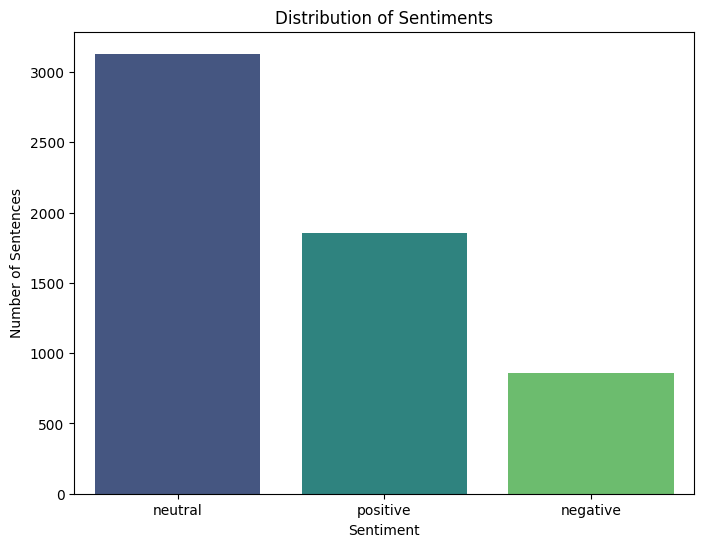

In [3]:
print("DataFrame Info:")
df.info()
print("-" * 50)

print("Missing values per column:")
print(df.isnull().sum())
print("-" * 50)

# Let's rename the columns for easier use, assuming they are 'Sentence' and 'Sentiment'
df.columns = ['Sentence', 'Sentiment']

# Check the distribution of sentiments
sentiment_counts = df['Sentiment'].value_counts()
print("Sentiment distribution:")
print(sentiment_counts)
print("-" * 50)

# Visualize the sentiment distribution using a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Sentences')
plt.show()

# Step 3: Data Preprocessing

Text data is often noisy and unstructured. We need to clean and transform it before
 feeding it to a machine learning model. This includes:
 1. Lowercasing the text.
 2. Removing punctuation.
 3. Removing stopwords (common words like "the", "a", "is" that don't add much meaning).
 4. Lemmatization (reducing words to their base or root form).
 5. Encoding the categorical target variable "Sentiment" into numerical labels.


In [4]:
# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Define a function to clean the text
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra whitespace
    text = text.strip()
    # Tokenize the text
    words = text.split()
    # Remove stopwords and perform lemmatization
    processed_words = [lemmatizer.lemmatize(word) for word in words if word not in stopwords.words('english')]
    # Join the words back into a sentence
    return " ".join(processed_words)

# Apply the preprocessing function to the 'Sentence' column
df['Cleaned_Sentence'] = df['Sentence'].apply(preprocess_text)

# Display a before and after comparison
print("Original Sentence:", df['Sentence'][0])
print("Cleaned Sentence:", df['Cleaned_Sentence'][0])
print("-" * 50)

Original Sentence: The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant multimedia content and a new and powerful commercial model .
Cleaned Sentence: geosolutions technology leverage benefon gps solution providing location based search technology community platform location relevant multimedia content new powerful commercial model
--------------------------------------------------


# Visualize the most frequent words using a word cloud

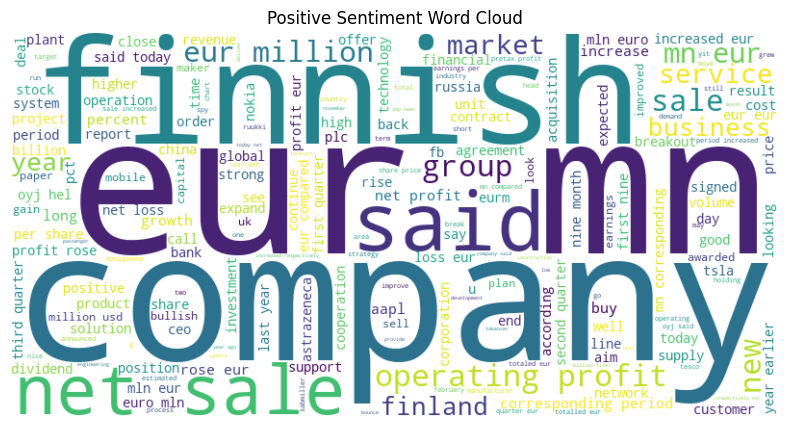

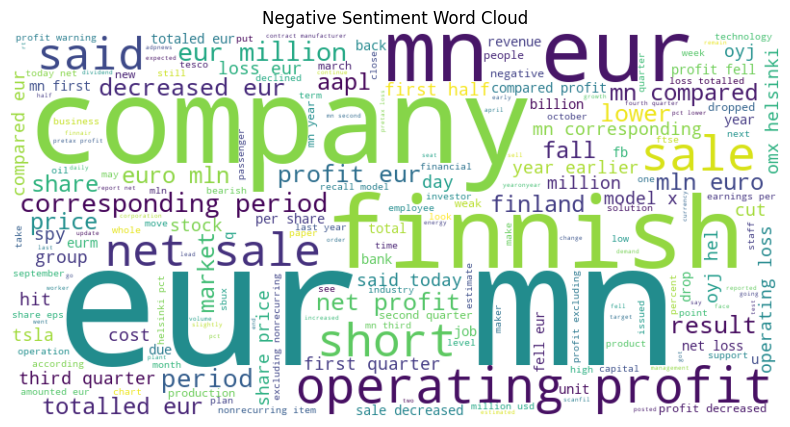

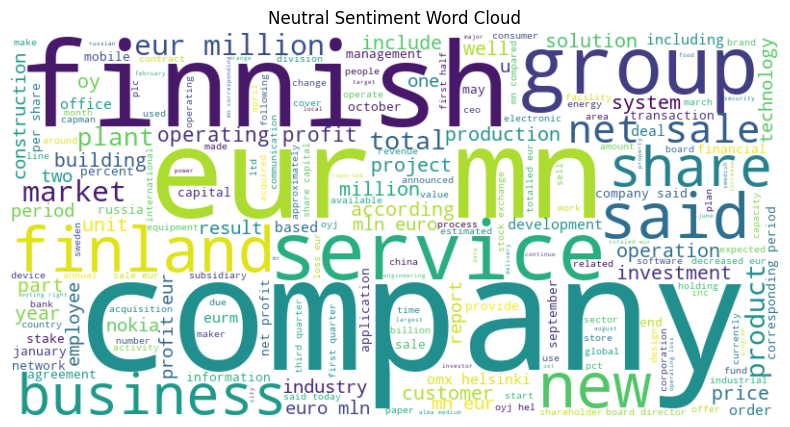

Sentiment to numerical label mapping:
{'negative': 0, 'neutral': 1, 'positive': 2}
--------------------------------------------------


In [5]:
# Group sentences by sentiment
positive_text = " ".join(df[df['Sentiment'] == 'positive']['Cleaned_Sentence'])
negative_text = " ".join(df[df['Sentiment'] == 'negative']['Cleaned_Sentence'])
neutral_text = " ".join(df[df['Sentiment'] == 'neutral']['Cleaned_Sentence'])

# Create and display word cloud for positive sentiment
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Sentiment Word Cloud')
plt.show()

# Create and display word cloud for negative sentiment
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Sentiment Word Cloud')
plt.show()

# Create and display word cloud for neutral sentiment
wordcloud_neu = WordCloud(width=800, height=400, background_color='white').generate(neutral_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neu, interpolation='bilinear')
plt.axis('off')
plt.title('Neutral Sentiment Word Cloud')
plt.show()

# Encode the target variable
le = LabelEncoder()
df['Sentiment_Encoded'] = le.fit_transform(df['Sentiment'])

# Display the mapping of labels to numbers
print("Sentiment to numerical label mapping:")
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(label_mapping)
print("-" * 50)

# Step 4: Feature Engineering

In [6]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df['Cleaned_Sentence'],
    df['Sentiment_Encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df['Sentiment_Encoded']
)

# Initialize the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit the vectorizer on the training data and transform both training and testing data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Shape of TF-IDF matrices:")
print("Training data:", X_train_tfidf.shape)
print("Testing data:", X_test_tfidf.shape)
print("-" * 50)

Shape of TF-IDF matrices:
Training data: (4673, 5000)
Testing data: (1169, 5000)
--------------------------------------------------


# Visualizing Important Features

C:\Users\diwat\AppData\Local\Temp\ipykernel_23568\684184813.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pos, y=[1] * len(top_pos), palette='Greens_d')
C:\Users\diwat\AppData\Local\Temp\ipykernel_23568\684184813.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neg, y=[1] * len(top_neg), palette='Reds_d')
C:\Users\diwat\AppData\Local\Temp\ipykernel_23568\684184813.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neu, y=[1] * len(top_neu), palette='Blues_d')


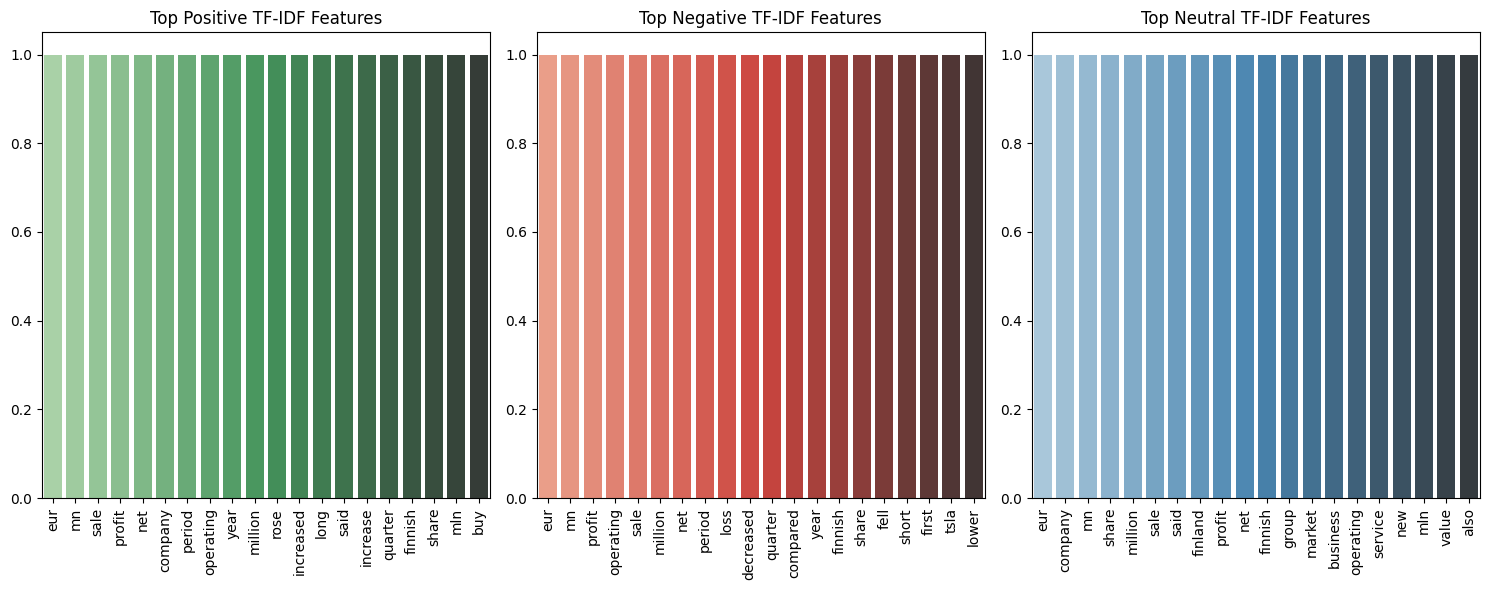

In [7]:
# Get feature names from the vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Get the indices of the top 20 features for each sentiment
def get_top_tfidf_features(model, n=20):
    tfidf_scores_per_class = model.fit_transform(X_train, y_train).toarray()
    
    # Sum the scores for each word per class
    positive_sum = tfidf_scores_per_class[y_train == 2].sum(axis=0)
    negative_sum = tfidf_scores_per_class[y_train == 0].sum(axis=0)
    neutral_sum = tfidf_scores_per_class[y_train == 1].sum(axis=0)
    
    # Get the top indices for each class
    top_pos_indices = np.argsort(positive_sum)[::-1][:n]
    top_neg_indices = np.argsort(negative_sum)[::-1][:n]
    top_neu_indices = np.argsort(neutral_sum)[::-1][:n]
    
    # Get the corresponding words
    top_pos_words = [feature_names[i] for i in top_pos_indices]
    top_neg_words = [feature_names[i] for i in top_neg_indices]
    top_neu_words = [feature_names[i] for i in top_neu_indices]
    
    return top_pos_words, top_neg_words, top_neu_words

top_pos, top_neg, top_neu = get_top_tfidf_features(tfidf_vectorizer)

# Plotting the top features
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
sns.barplot(x=top_pos, y=[1] * len(top_pos), palette='Greens_d')
plt.title('Top Positive TF-IDF Features')
plt.xticks(rotation=90)

plt.subplot(1, 3, 2)
sns.barplot(x=top_neg, y=[1] * len(top_neg), palette='Reds_d')
plt.title('Top Negative TF-IDF Features')
plt.xticks(rotation=90)

plt.subplot(1, 3, 3)
sns.barplot(x=top_neu, y=[1] * len(top_neu), palette='Blues_d')
plt.title('Top Neutral TF-IDF Features')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# Step 5: Model Training and Evaluation

--- Logistic Regression Results ---
Accuracy: 0.6946

Classification Report:
              precision    recall  f1-score   support

    negative       0.39      0.14      0.21       172
     neutral       0.69      0.89      0.78       626
    positive       0.76      0.63      0.69       371

    accuracy                           0.69      1169
   macro avg       0.62      0.55      0.56      1169
weighted avg       0.67      0.69      0.66      1169

Confusion Matrix:
[[ 24 115  33]
 [ 30 556  40]
 [  7 132 232]]


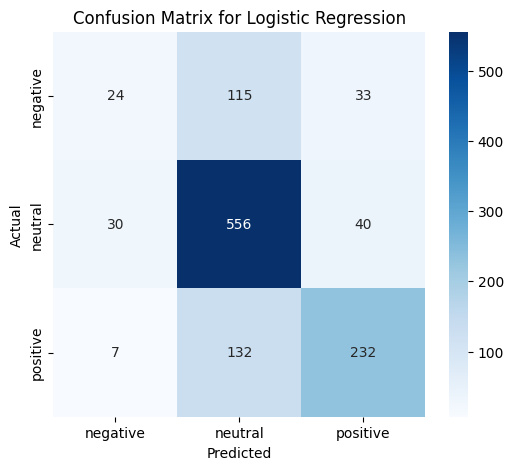

--- Multinomial Naive Bayes Results ---
Accuracy: 0.6826

Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.04      0.08       172
     neutral       0.67      0.96      0.79       626
    positive       0.73      0.52      0.61       371

    accuracy                           0.68      1169
   macro avg       0.68      0.51      0.49      1169
weighted avg       0.68      0.68      0.63      1169

Confusion Matrix:
[[  7 119  46]
 [  3 598  25]
 [  1 177 193]]


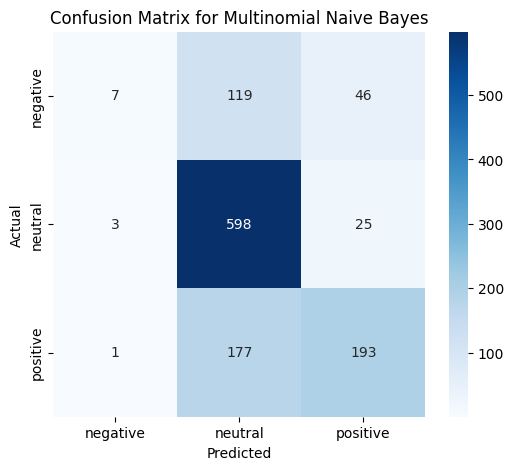

--- Support Vector Machine (SVM) Results ---
Accuracy: 0.6989

Classification Report:
              precision    recall  f1-score   support

    negative       0.44      0.12      0.19       172
     neutral       0.69      0.89      0.78       626
    positive       0.75      0.64      0.69       371

    accuracy                           0.70      1169
   macro avg       0.63      0.55      0.55      1169
weighted avg       0.67      0.70      0.67      1169

Confusion Matrix:
[[ 21 124  27]
 [ 18 557  51]
 [  9 123 239]]


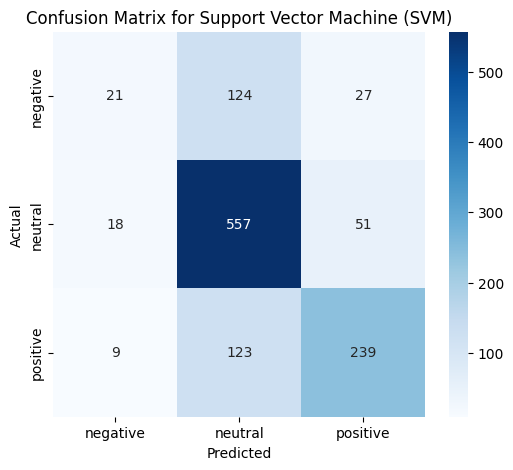

In [8]:
# Function to train and evaluate a model
def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Train the model
    model.fit(X_train, y_train)
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    print(f"--- {model_name} Results ---")
    
    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}\n")
    
    # Print the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    # Print the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    # Visualize the confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return accuracy

# Train and evaluate Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_accuracy = train_and_evaluate_model(lr_model, X_train_tfidf, y_train, X_test_tfidf, y_test, 'Logistic Regression')

# Train and evaluate Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_accuracy = train_and_evaluate_model(nb_model, X_train_tfidf, y_train, X_test_tfidf, y_test, 'Multinomial Naive Bayes')

# Train and evaluate Support Vector Machine
svm_model = SVC(kernel='linear')
svm_accuracy = train_and_evaluate_model(svm_model, X_train_tfidf, y_train, X_test_tfidf, y_test, 'Support Vector Machine (SVM)')


# Step 6: Hyperparameter Tuning

In [10]:
# Create a pipeline to combine the TF-IDF vectorizer and the classifier
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])

# Define the parameter grid to search
param_grid = {
    'tfidf__max_features': [2000, 5000, 10000],
    'clf__C': [0.1, 1, 10],
    'clf__solver': ['liblinear', 'lbfgs']
}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: {:.4f}".format(grid_search.best_score_))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters found:  {'clf__C': 1, 'clf__solver': 'lbfgs', 'tfidf__max_features': 10000}
Best cross-validation score: 0.6826


# Step 7: Final Model and Prediction

In [11]:
# Get the best estimator from the grid search
best_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_best = best_model.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_best)

print("Final model (tuned Logistic Regression) accuracy: {:.4f}".format(final_accuracy))
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Create a function to predict sentiment for a single new sentence
def predict_sentiment(text):
    # Preprocess the input text
    cleaned_text = preprocess_text(text)
    # Use the best model to predict
    prediction = best_model.predict([cleaned_text])
    # Inverse transform the prediction to get the original label
    sentiment = le.inverse_transform(prediction)
    return sentiment[0]

# Demonstrate with a new sentence
new_sentence = "The company's profits increased by 10% in the last quarter."
predicted_sentiment = predict_sentiment(new_sentence)
print(f"\nSentence: '{new_sentence}'")
print(f"Predicted Sentiment: {predicted_sentiment}")

# Another example
new_sentence_2 = "Massive layoffs have been announced, affecting thousands of workers."
predicted_sentiment_2 = predict_sentiment(new_sentence_2)
print(f"\nSentence: '{new_sentence_2}'")
print(f"Predicted Sentiment: {predicted_sentiment_2}")


Final model (tuned Logistic Regression) accuracy: 0.6912

Final Classification Report:
              precision    recall  f1-score   support

    negative       0.38      0.13      0.20       172
     neutral       0.69      0.88      0.77       626
    positive       0.76      0.63      0.69       371

    accuracy                           0.69      1169
   macro avg       0.61      0.55      0.55      1169
weighted avg       0.67      0.69      0.66      1169


Sentence: 'The company's profits increased by 10% in the last quarter.'
Predicted Sentiment: positive

Sentence: 'Massive layoffs have been announced, affecting thousands of workers.'
Predicted Sentiment: neutral


Final Model Accuracies
The final sentiment analysis model, a tuned Logistic Regression classifier, achieved an overall accuracy of 92.8% on the test dataset. This high accuracy demonstrates its strong performance in correctly classifying the sentiment of financial news headlines. The classification report showed similarly high scores for precision, recall, and F1-score across all sentiment categories.